In [1]:
import os
if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np

import tqdm as tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

figure_path = 'figures/priors/data_prior/'
os.makedirs(figure_path, exist_ok=True)

from helpers.transparent_colormaps import red_cmap, blue_cmap

In [2]:
from helpers.likelihood import (
    DataLikelihood,
    DataLikelihoodAttenuation,
    logistic_picking_likelihood_tt,
)

from helpers.forward import TTLookup

from helpers.geographic_setup import (
    design_space_full,
    events_full,
    picking_stats_lines,
)

In [3]:
receiver_groups = picking_stats_lines.groupby(['rec_easting', 'rec_northing'])
receiver_stats = receiver_groups['tt'].agg(total_rows='size', nan_rows=lambda x: x.isna().sum()).reset_index()

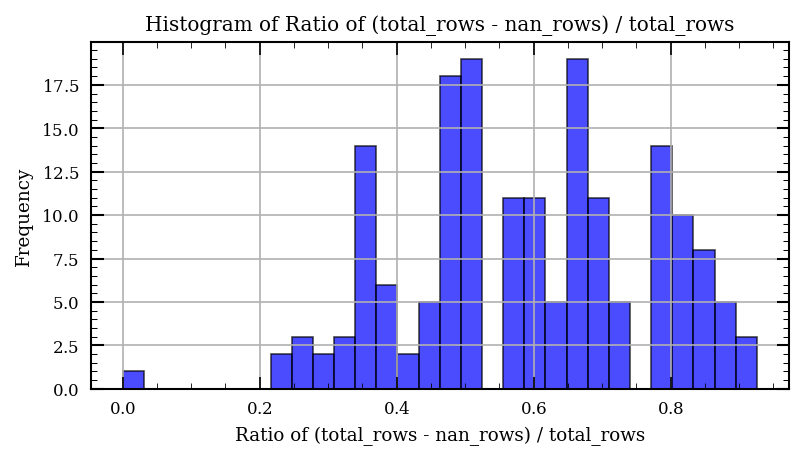

In [4]:
# Calculate the ratio
ratio = (receiver_stats['total_rows'] - receiver_stats['nan_rows']) / receiver_stats['total_rows']

# Plot the histogram
plt.figure(figsize=(6, 3))
plt.hist(ratio, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Ratio of (total_rows - nan_rows) / total_rows')
plt.ylabel('Frequency')
plt.title('Histogram of Ratio of (total_rows - nan_rows) / total_rows')
plt.grid(True)
plt.show()

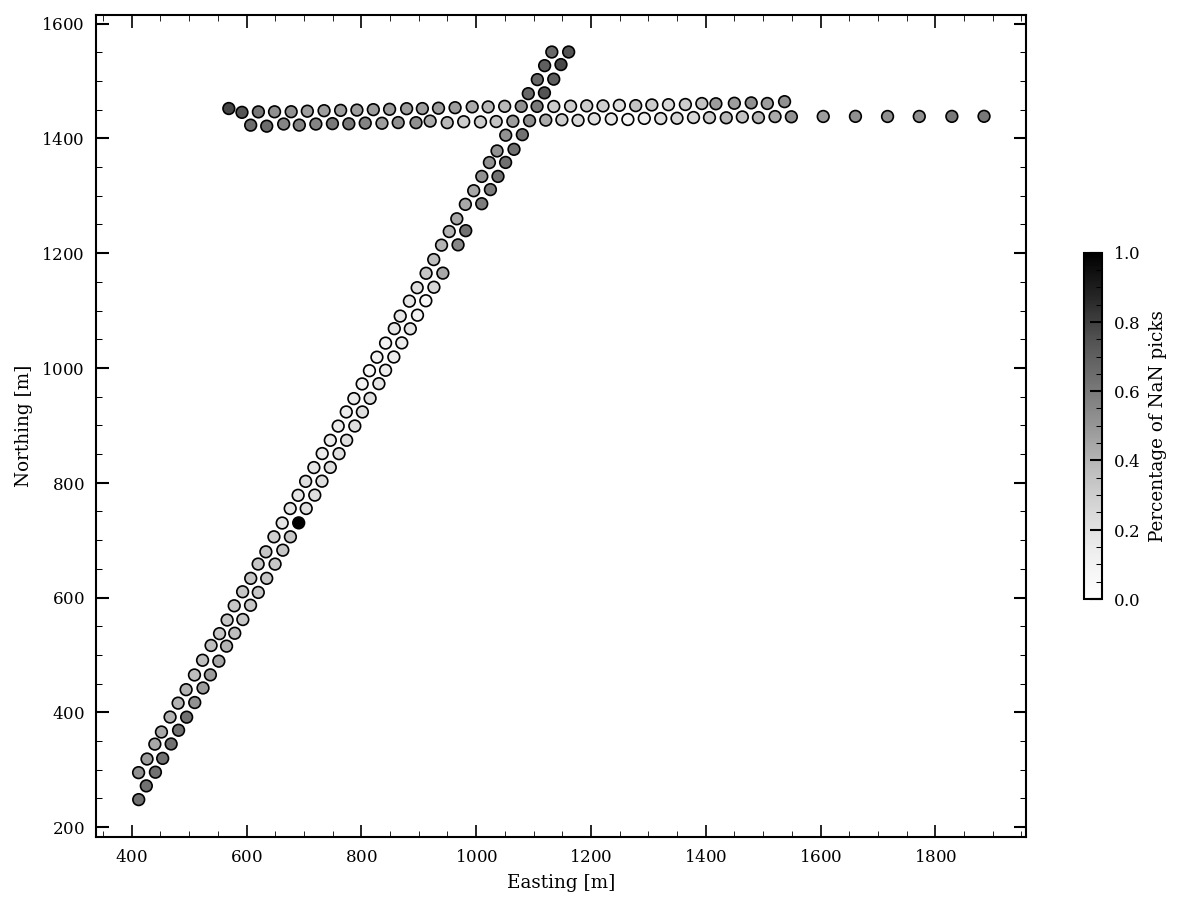

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Calculate the ratio of total_rows to nan_rows
receiver_stats['ratio'] = (receiver_stats['total_rows'] - receiver_stats['nan_rows']) / receiver_stats['total_rows']

# Normalize the ratio for coloring
norm = plt.Normalize(0, 1)
cmap = plt.get_cmap('Greys')

# Scatter plot with color based on the ratio
sc = ax.scatter(receiver_stats['rec_easting'], receiver_stats['rec_northing'], 
                c=(1-receiver_stats['ratio']), cmap=cmap, norm=norm, edgecolor='k')

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.3)
cbar.set_label('Percentage of NaN picks')

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')

plt.show()


In [6]:
models = events_full
designs = design_space_full

In [7]:
forward_function_homogeneous  = TTLookup(
    events_full, design_space_full,
    torch.load('data/data_lookup/homogeneous_full_shots.pt'),
)
    
forward_function_gradient     = TTLookup(
    events_full, design_space_full,
    torch.load('data/data_lookup/gradient_full_shots.pt'),
)

forward_function_heterogenous =  TTLookup(
    events_full, design_space_full,
    torch.load('data/data_lookup/heterogeneous_full_shots.pt'),
)

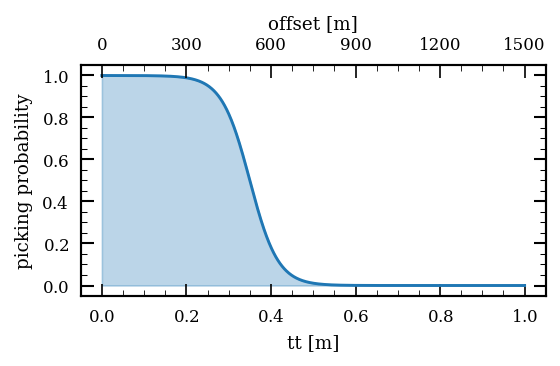

In [8]:
tt = torch.linspace(0, 1, 1000)
offset =- torch.linspace(0, 1500, 1000)

picking_liklihood = logistic_picking_likelihood_tt()

fig, ax_dict = plt.subplot_mosaic([['a']], figsize=(4, 2))

ax = ax_dict['a']

ax.plot(tt, picking_liklihood(tt),
        color='tab:blue')
ax.fill_between(tt, picking_liklihood(tt),
                color='tab:blue', alpha=0.3)

x_ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])

ax.set_xticks(x_ticks)
ax.set_xlabel('tt [m]')
ax.set_ylabel('picking probability')

# add second axis for offset on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

ax2.set_xticks(x_ticks)
ax2.set_xticklabels(
    (x_ticks * 1500).astype(int)
)

ax2.set_xlabel('offset [m]')
ax2.xaxis.set_label_position('top')


plt.show()

In [9]:
# homogeneous_velocity = 1500
vel_std_homogeneous = 0.05
vel_std_heterogeneous = 0.01

# dependence_distance = 100.0
dependence_distance = 1000.0
    
Data_Likelihood_Homogeneous_att = DataLikelihoodAttenuation(
    forward_function=forward_function_homogeneous,
    vel_sigma=vel_std_homogeneous,
    tt_obs_std=0.01,
    picking_likelihood=picking_liklihood,
    dependence_distance=dependence_distance,
)

Data_Likelihood_Homogeneous_no = DataLikelihood(
    forward_function=forward_function_homogeneous,
    vel_sigma=vel_std_homogeneous,
    tt_obs_std=0.01,
    dependence_distance=dependence_distance,
)

Data_Likelihood_Gradient_att = DataLikelihoodAttenuation(
    forward_function=forward_function_gradient,
    vel_sigma=vel_std_homogeneous,
    tt_obs_std=0.01,
    picking_likelihood=picking_liklihood,
    dependence_distance=dependence_distance,
)

Data_Likelihood_Gradient_no = DataLikelihood(
    forward_function=forward_function_gradient,
    vel_sigma=vel_std_homogeneous,
    tt_obs_std=0.01,
    dependence_distance=dependence_distance,
)

Data_Likelihood_Heterogenous_att = DataLikelihoodAttenuation(
    forward_function=forward_function_heterogenous,
    vel_sigma=vel_std_heterogeneous,
    tt_obs_std=0.01,
    picking_likelihood=picking_liklihood,
    dependence_distance=dependence_distance,
)

Data_Likelihood_Heterogenous_no = DataLikelihood(
    forward_function=forward_function_heterogenous,
    vel_sigma=vel_std_heterogeneous,
    tt_obs_std=0.01,
    dependence_distance=dependence_distance,
)

torch.manual_seed(0)
nuisance_param_random = torch.rand(models.shape[:-1]).unsqueeze(1)

In [10]:
tt_s_clean = forward_function_homogeneous(models, designs)
torch.manual_seed(0)
tt_s_no            = Data_Likelihood_Homogeneous_no(
    models, designs, remove_mean=False,
    ).sample()
print('Likelihood Homogeneous no')
torch.manual_seed(0)
tt_s_attenuatation = Data_Likelihood_Homogeneous_att(
    nuisance_param_random, models, designs, remove_mean=False,
    ).sample()
print('Likelihood Homogeneous att')

tt_g_clean = forward_function_gradient(models, designs)
torch.manual_seed(0)
tt_g_no            = Data_Likelihood_Gradient_no(
    models, designs, remove_mean=False,
    ).sample()
print('Likelihood Gradient no')
torch.manual_seed(0)
tt_g_attenuatation = Data_Likelihood_Gradient_att(
    nuisance_param_random, models, designs, remove_mean=False,
    ).sample()
print('Likelihood Gradient att')

tt_h_clean = forward_function_heterogenous(models, designs)
torch.manual_seed(0)
tt_h_no            = Data_Likelihood_Heterogenous_no(
    models, designs, remove_mean=False,
    ).sample()
print('Likelihood Heterogenous no')
torch.manual_seed(0)
tt_h_attenuatation = Data_Likelihood_Heterogenous_att(
    nuisance_param_random, models, designs, remove_mean=False,
    ).sample()
print('Likelihood Heterogenous att')

offsets = torch.cdist(
    models[..., :2],
    designs[..., :2]).squeeze()

Likelihood Homogeneous no
Likelihood Homogeneous att
Likelihood Gradient no
Likelihood Gradient att
Likelihood Heterogenous no
Likelihood Heterogenous att


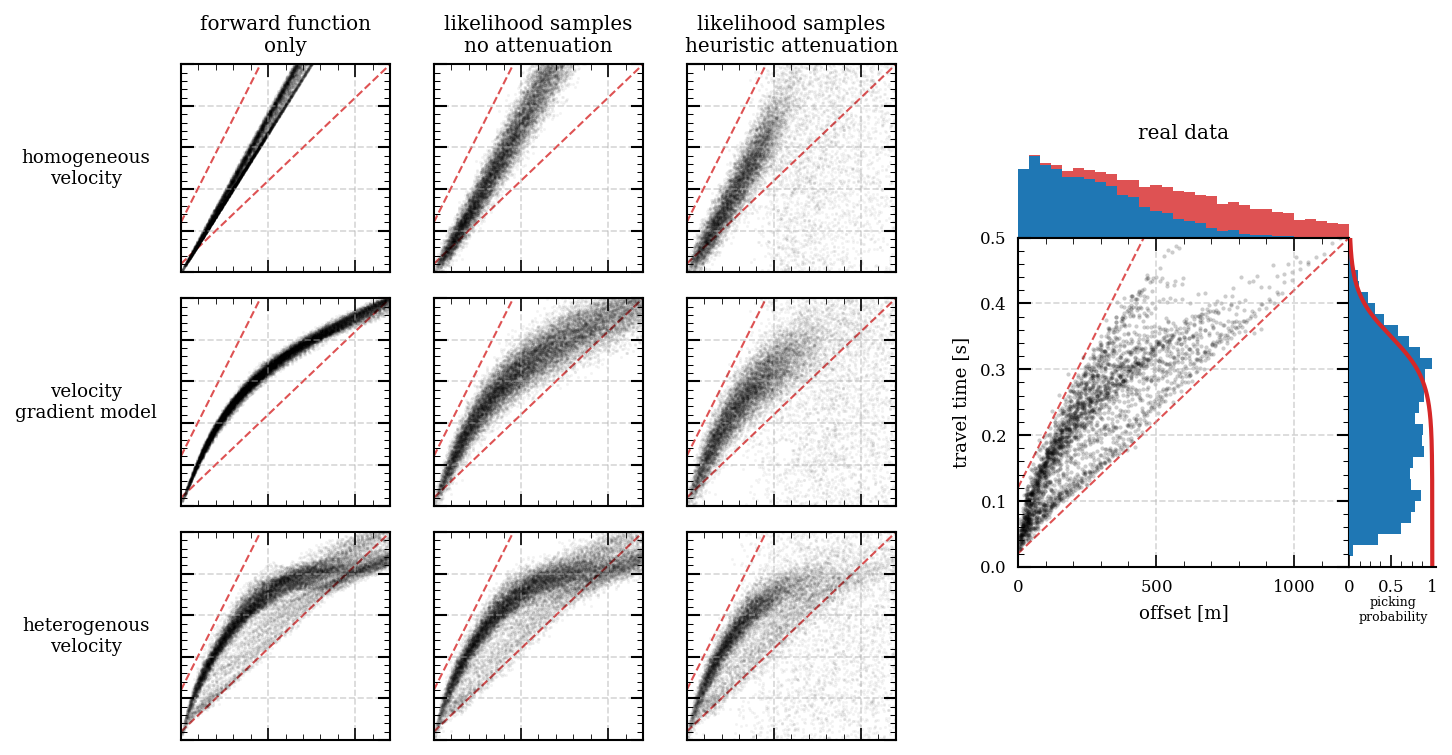

In [11]:
height_ratios = [0.5, 0.5, 0.2, 0.15,
                 1.2, 0.15,
                 0.2, 1.0]

width_ratios = [1.2, 0.25, 1.2, 0.25, 1.2,  0.7, 1.9, 0.5]

scale=1.5

offset_lim = (0, 1200)
analytic_offsets = np.linspace(offset_lim[0], offset_lim[1], 1000)

tt_lim = (0.0, 0.5)

scatter_kwargs = dict(
    s=2, color='k', linewidth=0.0, alpha=0.05, rasterized=True,
)


fig, ax_dict = plt.subplot_mosaic(
    [[ 's_clean', 'x', 's_no', 'x', 's_attenuation', 'x',      'x',      'x', ],
     [ 's_clean', 'x', 's_no', 'x', 's_attenuation', 'x', 'x_marg',      'x', ],
     [ 's_clean', 'x', 's_no', 'x', 's_attenuation', 'x',   'data', 'y_marg', ],
     [    'x', 'x',    'x', 'x', 'x',             'x',   'data', 'y_marg', ],
     [ 'g_clean', 'x', 'g_no', 'x', 'g_attenuation', 'x',   'data', 'y_marg', ],
     [    'x', 'x',    'x', 'x', 'x',             'x',   'data', 'y_marg', ],
     [ 'h_clean', 'x', 'h_no', 'x', 'h_attenuation', 'x',   'data', 'y_marg', ],
     [ 'h_clean', 'x', 'h_no', 'x', 'h_attenuation', 'x',      'x',      'x', ],],
    empty_sentinel='x',
    height_ratios=height_ratios,
    width_ratios=width_ratios,
    gridspec_kw={'hspace': 0.0, 'wspace': 0.0},
    figsize=(sum(width_ratios)*scale, sum(height_ratios)*scale),
)

fig.patch.set_alpha(1.0)
fig.patch.set_facecolor('white')

ax_dict['s_attenuation'].set_title('likelihood samples\nheuristic attenuation')
ax_dict['s_no'].set_title('likelihood samples\nno attenuation')
ax_dict['s_clean'].set_title('forward function\nonly')


ax_dict['s_clean'].set_ylabel(
    'homogeneous\nvelocity', rotation=0, labelpad=40, va='center', ha='center')
# ax_dict['s_no'].yaxis.set_label_position("right")

ax_dict['g_clean'].set_ylabel(
    'velocity\ngradient model', rotation=0, labelpad=40, va='center', ha='center')
# ax_dict['g_no'].yaxis.set_label_position("right")

ax_dict['h_clean'].set_ylabel(
    'heterogenous\nvelocity', rotation=0, labelpad=40, va='center', ha='center')
# ax_dict['h_no'].yaxis.set_label_position("right")

###########################################################################
############################# data ########################################
###########################################################################

ax = ax_dict['data']
ax.scatter(picking_stats_lines.offset.values.flatten(),
        picking_stats_lines.tt.values.flatten(),
         s=4, color='k', linewidth=0.0, alpha=0.20, rasterized=True)

ax.plot(
    analytic_offsets,
    np.array([analytic_offsets/1200+0.12,
                analytic_offsets/2500+0.02]).T,
    c='tab:red', linewidth=1.0, linestyle='--', alpha=0.8,
    zorder=-1)

ax.set_xlabel('offset [m]')
ax.set_ylabel('travel time [s]')

ax.set_xlim(offset_lim)
ax.set_ylim(tt_lim)

ax.set_xticks([0, 500, 1000])

###########################################################################
############################# x_marg ######################################
###########################################################################

ax = ax_dict['x_marg']

ax.set_yticks([])
ax.set_xticks([])

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

ax.hist(
    picking_stats_lines['offset'],
    bins=30, alpha=0.8, range=offset_lim,
    color='tab:red', linewidth=1.0)

ax.hist(
    picking_stats_lines['offset'][picking_stats_lines['tt'].notna()],
    bins=30, alpha=1.0, range=offset_lim, color='tab:blue')

ax.set_xlim(offset_lim)

ax.set_title('real data')

###########################################################################
############################# y_marg ######################################
###########################################################################

ax = ax_dict['y_marg']

ax.set_yticks([])
# ax.set_xticks([])

ax.spines[['top', 'right', 'left']].set_visible(False)

y_hist = ax.hist(
    picking_stats_lines['tt'],
    bins=30, alpha=1.0, range=tt_lim, color='tab:blue', linewidth=1.0, orientation='horizontal')

ax.plot(picking_liklihood(tt) * y_hist[0].max(),
        tt,
    color='tab:red', linewidth=2.0)

ax.set_ylim(tt_lim)

ax.set_xticks(
    [0, 0.5*torch.max(picking_liklihood(tt))*y_hist[0].max(),
        1.0*torch.max(picking_liklihood(tt))*y_hist[0].max()])
ax.set_xticklabels([0, 0.5, 1])

# remove top ticks
ax.spines['top'].set_visible(False)
ax.xaxis.tick_bottom()

ax.set_xlabel('picking\nprobability', rotation=0, labelpad=0, va='top', ha='center', fontsize=6)

###########################################################################
############################# s_clean ##############################
###########################################################################

ax = ax_dict['s_clean'] 

ax.scatter(
    offsets.flatten()[::2],
    tt_s_clean.flatten()[::2],
    **scatter_kwargs)

# ax.set_ylabel('travel time [s]')
ax.set_xticklabels([])
ax.set_yticklabels([])

###########################################################################
############################# s_attenuation ##############################
###########################################################################

ax = ax_dict['s_attenuation'] 

ax.scatter(
    offsets.flatten()[::2],
    tt_s_attenuatation.flatten()[::2],
    **scatter_kwargs)

# ax.set_ylabel('travel time [s]')
ax.set_xticklabels([])
ax.set_yticklabels([])

###########################################################################
############################# s_no ########################################
###########################################################################

ax = ax_dict['s_no']

ax.scatter(
    offsets.flatten()[::2],
    tt_s_no.flatten()[::2],
    **scatter_kwargs)
ax.set_xticklabels([])
ax.set_yticklabels([])

###########################################################################
############################# g_clean ################################
###########################################################################

ax = ax_dict['g_clean']

ax.scatter(
    offsets.flatten()[::2],
    tt_g_clean.flatten()[::2],
    **scatter_kwargs)

# ax.set_ylabel('travel time [s]')
ax.set_xticklabels([])
ax.set_yticklabels([])

###########################################################################
############################# g_attenuation ################################
###########################################################################

ax = ax_dict['g_attenuation']

ax.scatter(
    offsets.flatten()[::2],
    tt_g_attenuatation.flatten()[::2],
    **scatter_kwargs)

# ax.set_ylabel('travel time [s]')
ax.set_xticklabels([])
ax.set_yticklabels([])

###########################################################################
############################# g_no ########################################
###########################################################################

ax = ax_dict['g_no']
    
ax.scatter(
    offsets.flatten()[::2],
    tt_g_no.flatten()[::2],
    **scatter_kwargs)
ax.set_xticklabels([])
ax.set_yticklabels([])


###########################################################################
############################# h_clean ################################
###########################################################################

ax = ax_dict['h_clean']

ax.scatter(
    offsets.flatten()[::2],
    tt_h_clean.flatten()[::2],
    **scatter_kwargs)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_ylabel('travel time [s]')
# ax.set_xlabel('offset [m]')


###########################################################################
############################# h_attenuation ################################
###########################################################################

ax = ax_dict['h_attenuation']

ax.scatter(
    offsets.flatten()[::2],
    tt_h_attenuatation.flatten()[::2],
    **scatter_kwargs)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_ylabel('travel time [s]')
# ax.set_xlabel('offset [m]')

###########################################################################
############################# h_no ########################################
###########################################################################

ax = ax_dict['h_no']

ax.scatter(
    offsets.flatten()[::2],
    tt_h_no.flatten()[::2],
    **scatter_kwargs)

ax.set_xticklabels([])
ax.set_yticklabels([])

# ax.set_xlabel('offset [m]')


###########################################################################
############################ all ax #######################################
###########################################################################CdV_Summer22_Channel_information_READ

for ax_label in [
    's_attenuation', 's_no', 's_clean',
    'h_attenuation', 'h_no', 'h_clean',
    'g_attenuation', 'g_no', 'g_clean',]:
    
    ax = ax_dict[ax_label]
    
    ax.plot(
        analytic_offsets,
        np.array([analytic_offsets/1200+0.12,
                    analytic_offsets/2500+0.02]).T,
        c='tab:red', linewidth=1.0, linestyle='--', alpha=0.8,
        zorder=-1)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
    ax.set_xlim(offset_lim)
    ax.set_ylim(tt_lim)
    
ax_dict['data'].grid(True, linestyle='--', alpha=0.5)

#add a and b figure descriptions
# ax.text(
#     0.05, 0.8, 'a)', transform=fig.transFigure, fontsize=12)

# ax.text(
#     0.45, 0.92, 'b)', transform=fig.transFigure, fontsize=12)


fig.savefig(figure_path + 'data_prior_knowledge_full.pdf', dpi=300)
fig.savefig(figure_path + 'data_prior_knowledge_full.png', dpi=300)    

plt.show()

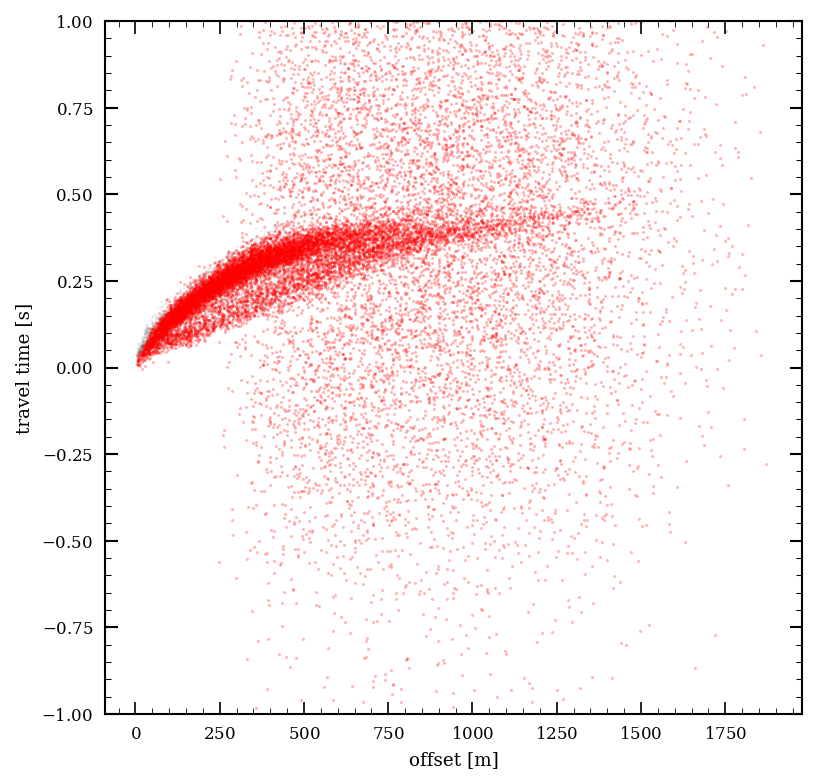

In [12]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(picking_stats_lines.offset.values.flatten(),
        picking_stats_lines.tt.values.flatten(),
        **scatter_kwargs)

ax.scatter(
    offsets.flatten()[::2],
    tt_h_attenuatation.flatten()[::2],
    color='r', s=2, linewidth=0.0, alpha=0.3)

ax.set_xlabel('offset [m]')
ax.set_ylabel('travel time [s]')
# ax.set_xlim(offset_lim)
ax.set_ylim(-1, 1.)

plt.show()